# Objective :-
the goal is to predict whether a passenger survived the titanic disaster or not based on demographic and travel related features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,roc_auc_score,matthews_corrcoef,roc_curve,auc
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

Load Dataset

In [2]:
df = pd.read_csv(r"E:\Besant_Technology\Data Science\Classification\Titanic-Dataset.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Variable	Definition	Key<br>
survival	Survival	0 = No, 1 = Yes<br>
pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd<br>
sex	Sex	<br>
Age	Age in years	<br>
sibsp	# of siblings / spouses aboard the Titanic<br>	
parch	# of parents / children aboard the Titanic<br>	
ticket	Ticket number<br>	
fare	Passenger fare	<br>
cabin	Cabin number	<br>
embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

Basic Data inspection

In [3]:
df.shape

(891, 12)

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Drop unnecessary column

In [8]:
df = df.drop(columns =  ['PassengerId', 'Name', 'Ticket','Cabin'], axis = 1)

In [9]:
#df.columns

Check for duplicate values and if it's there remove them

In [10]:
df.duplicated().sum()

np.int64(111)

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.shape

(780, 8)

Check for the null values

In [13]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         104
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Filling the NULL Values.

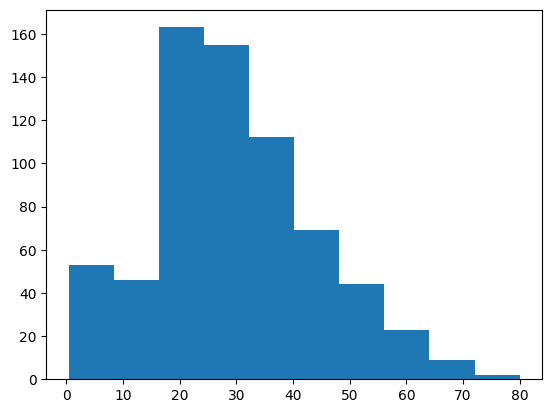

In [14]:
plt.hist(df['Age'])
plt.show()

In [15]:
df['Age'].mean(), df['Age'].median()

(np.float64(29.81275147928994), np.float64(28.0))

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 780, dtype: float64

In [17]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\baran\AppData\Local\Temp\ipykernel_6732\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [18]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Exploratory Data Analysis(EDA)

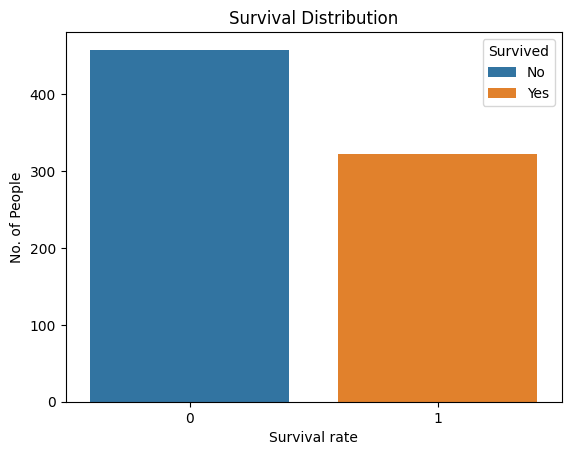

In [19]:
sns.countplot(x = 'Survived', data = df, hue = "Survived" )
plt.title('Survival Distribution')
plt.xlabel('Survival rate')
plt.ylabel('No. of People')
plt.legend(title = "Survived", labels = ['No', 'Yes'])
plt.show()

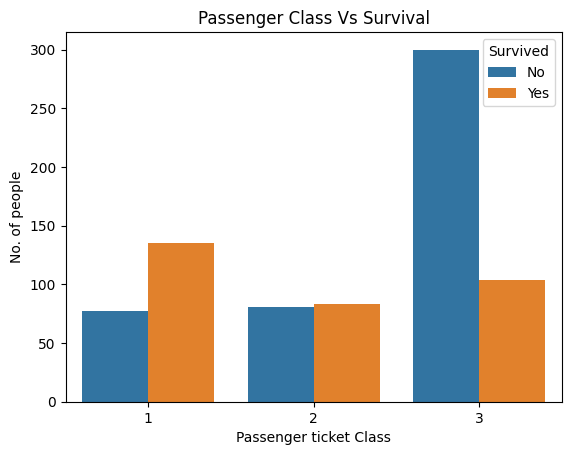

In [20]:
sns.countplot(x = "Pclass",data = df, hue = "Survived")
plt.title("Passenger Class Vs Survival")
plt.xlabel('Passenger ticket Class')
plt.ylabel('No. of people')
plt.legend(title = "Survived", labels = ['No', 'Yes'])
plt.show()

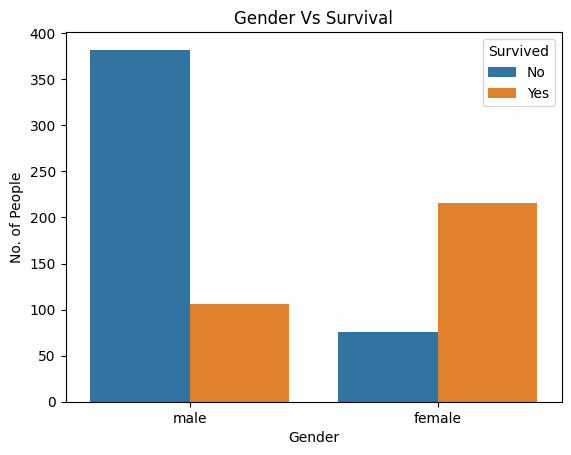

In [21]:
sns.countplot(x = "Sex", data = df, hue = "Survived")
plt.title("Gender Vs Survival")
plt.xlabel('Gender')
plt.ylabel('No. of People')
plt.legend(title = "Survived", labels = ['No', 'Yes'])
plt.show()

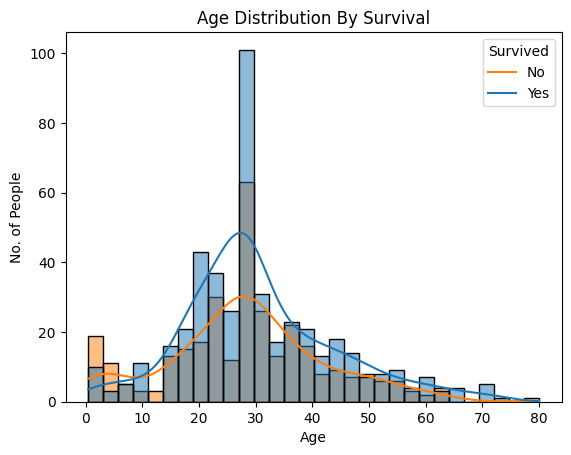

In [22]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution By Survival")
plt.xlabel("Age")
plt.ylabel("No. of People")
plt.legend(title = "Survived", labels = ['No', 'Yes'])
plt.show()

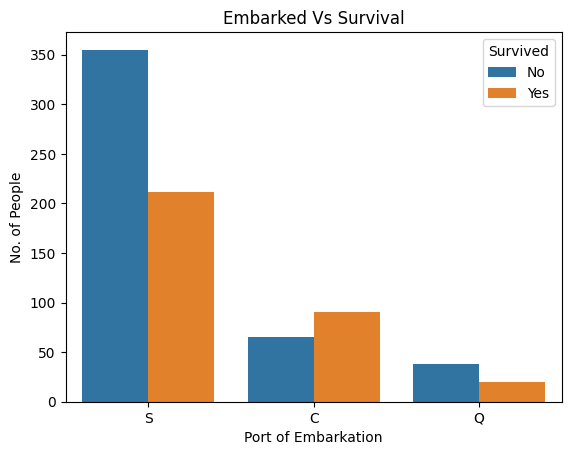

In [23]:
#embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Embarked Vs Survival")
plt.xlabel("Port of Embarkation")
plt.ylabel("No. of People")
plt.legend(title = "Survived", labels = ['No', 'Yes'])
plt.show()


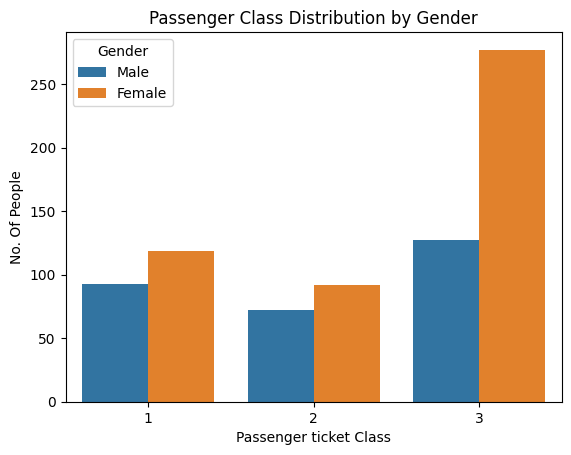

In [24]:
sns.countplot(x='Pclass', data=df, hue='Sex')
plt.title('Passenger Class Distribution by Gender')
plt.xlabel("Passenger ticket Class")
plt.ylabel("No. Of People")
plt.legend(title = "Gender", labels = ['Male', 'Female'])
plt.show()

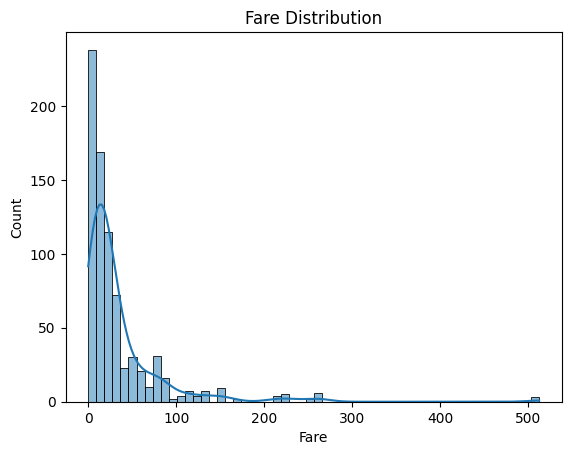

In [25]:
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.show()

In [26]:
cor = df.select_dtypes(['int', 'float']).corr()
cor

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.336244,-0.077843,-0.037597,0.069669,0.246669
Pclass,-0.336244,1.000000,-0.341238,0.086788,0.038975,-0.552440
Age,-0.077843,-0.341238,1.000000,-0.278655,-0.182174,0.092566
SibSp,-0.037597,0.086788,-0.278655,1.000000,0.380596,0.134127
Parch,0.069669,0.038975,-0.182174,0.380596,1.000000,0.191055
Fare,0.246669,-0.552440,0.092566,0.134127,0.191055,1.000000


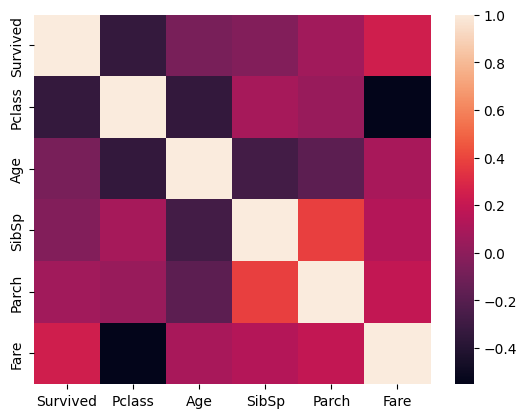

In [27]:
sns.heatmap(cor)
plt.show()

Convert Categorical data into numerical data.

In [28]:
df.dtypes[df.dtypes == "object"]. index

Index(['Sex', 'Embarked'], dtype='object')

In [29]:
# Using one hot Encoding
df = pd.get_dummies(df, columns = ['Sex','Embarked'])

In [30]:
df.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_female       bool
Sex_male         bool
Embarked_C       bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

Outlier Detection

The outliers in titanic dataset are genuine and informative.Instead of removing them handle them with log transformation, robust scaling or using feature engineering.let's see how these columns outlier give some information----
1. Fare :- very high ticket price shows the price of 1st class luxury.
2. Sibsp :- large number of family members are traveling together.
3. Age :- infants or the old people are traveling.
4. Parch :- large number of families(group of parents and children)

Generate a column name as Family_size and calculate the values for them.

In [31]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

Log transform for Fare

In [32]:
df['Fare_log'] = np.log1p(df['Fare'])

Convert the data into feature and target

In [33]:
X = df.drop(columns = 'Survived', axis = 1)
y = df['Survived']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [35]:
r = RobustScaler()
X_train_scaled = r.fit_transform(X_train)
X_test_scaled = r.transform(X_test)

In [36]:
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred = knn_base.predict(X_test_scaled)
y_pred_prob = knn_base.predict_proba(X_test_scaled)[:, 1]

In [38]:
#y_pred_prob

In [39]:
accuracy_score(y_pred = y_pred, y_true = y_test)

0.7435897435897436

In [40]:
estimator = KNeighborsClassifier()
param_grid = {
    "n_neighbors" : list(range(1,100,2)),
    "metric" : ['cityblock', 'euclidean', 'manhattan', 'minkowski']
}
cv = 5

In [41]:
grid = GridSearchCV(estimator = estimator, param_grid = param_grid, cv = cv)
grid.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['cityblock', 'euclidean', ...], 'n_neighbors': [1, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,27


In [42]:
grid.best_params_, grid.best_score_

({'metric': 'euclidean', 'n_neighbors': 27}, np.float64(0.7801167639699751))

In [49]:
knn_grid = KNeighborsClassifier(n_neighbors = 27, metric = 'euclidean')
knn_grid.fit(X, y)
y_pred_grid = knn_grid.predict(X_test_scaled)
score_grid = accuracy_score(y_test, y_pred)
score_grid

c:\Users\baran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.7435897435897436

In [43]:
rand = RandomizedSearchCV(estimator = estimator, param_distributions = param_grid, cv = cv)
rand.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_distributions,"{'metric': ['cityblock', 'euclidean', ...], 'n_neighbors': [1, 3, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [44]:
rand.best_params_, rand.best_score_

({'n_neighbors': 15, 'metric': 'euclidean'}, np.float64(0.7690909090909092))

In [ ]:
knn_rand = KNeighborsClassifier(n_neighbors = 15, metric = 'manhattan')
knn_rand.fit(X,y)
y_pred_rand = knn_rand.predict(X_test_scaled)
knn_rand_score = accuracy_score(y_test, y_pred)
knn_rand_score

c:\Users\baran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.7435897435897436

In [51]:
print(confusion_matrix(y_test, y_pred))

[[106  29]
 [ 31  68]]


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       135
           1       0.70      0.69      0.69        99

    accuracy                           0.74       234
   macro avg       0.74      0.74      0.74       234
weighted avg       0.74      0.74      0.74       234



In [53]:
y_pred_prob = rand.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
roc_auc

0.8199775533108866

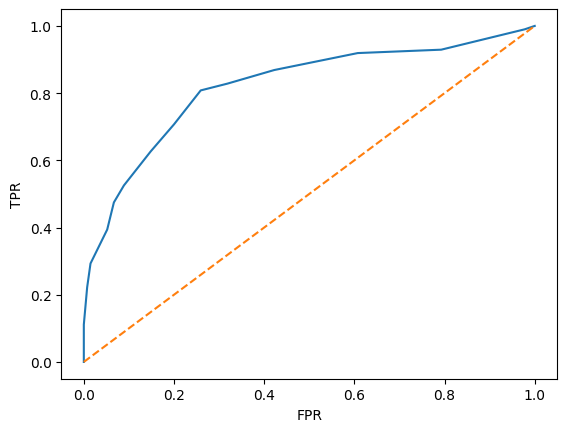

In [54]:
plt.plot(fpr,tpr, label = f"KNN (AUC= {roc_auc : .3f})")
plt.plot([0,1],[0,1], linestyle = "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()